<a href="https://colab.research.google.com/github/Sampurnanand-exe/A-complete-beginner-friendly-Data-Science-project-using-pure-Python./blob/main/ASOS_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

df = pd.read_csv('/content/drive/MyDrive/Data Notebooks/ASOS Analysis/products_asos.csv', engine='python', on_bad_lines='warn')

df['price'] = pd.to_numeric(df['price'], errors = 'coerce')
df = df.dropna(subset=['price'])

df.head()

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by' in text:
    try:
      return text.split('by')[1].split(' ')[1]
    except:
      return "Unknown"

  return "Unknown"

df['brand_row'] = df['description'].apply(get_brand)

In [ ]:
df.head(2)

,url,name,size,category,price,color,sku,description,images,brand_row
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [ ]:
brand_map = {

    'New' : 'New Look',
    'River' : 'River Island',
    'Miss' : 'Miss Selfridge',
    'TopshopWelcome' : 'Topshop'
}

df['Brand'] = df['brand_row'].map(brand_map).fillna(df['brand_row'])

brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index

df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [ ]:
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0

  sizes = size_str.split(',')
  total_sizes = len(sizes)

  out_of_stock_count = size_str.count('Out of stock')
  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate

metrices = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))
df_clean['Stockout_Count'] = [x[0] for x in metrices]
df_clean['Stockout_Rate'] = [x[1] for x in metrices]

df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stockout_Count']

cols = ['Brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue']
print(df_clean.sort_values(by = 'Lost_Revenue', ascending=False).head()[cols])

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


/tmp/ipykernel_568/1930563847.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


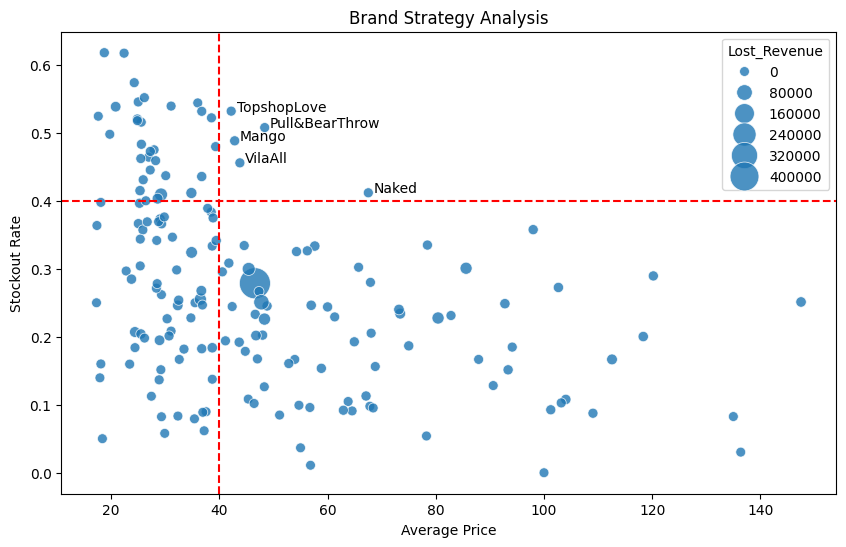

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price' : 'mean',
    'Stockout_Rate' : 'mean',
    'Lost_Revenue' : 'sum',
    'name' : 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data = brand_strategy,
    x = 'price',
    y = 'Stockout_Rate',
    size = 'Lost_Revenue',
    sizes = (50,500),
    alpha = 0.8,
    palette = 'viridis'
)

winners = brand_strategy[
    (brand_strategy['price'] > 40) &
    (brand_strategy['Stockout_Rate'] > 0.4)
]

for i in range(len(winners)):
  plt.text(
      winners.iloc[i]['price']+1,
      winners.iloc[i]['Stockout_Rate'],
      winners.iloc[i]['Brand']
  )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')

plt.axvline(x = 40, color = 'red', linestyle = '--')
plt.axhline(y = 0.4, color = 'red', linestyle = '--')

plt.show()
